# Data analysis. Lab 6. Working with `pandas`, part 3

## 1. Handling missing values

Missing data is quite common in the real world. There are various reasons for its occurrence, such as errors in measuring devices, data transmission, character encoding, incorrect recording, or the inclusion of null values in the source data, such as in a database.

Missing data is quite common in the real world. The causes can vary, such as errors in measuring devices, data transmission, character encoding, incorrect recording, or allowing `null` values in the source data, e.g., in a database.

There are several common ways to handle missing data:

1. **Removing records (observations)** that contain missing data (in the case of pandas or numpy, these are values represented by the `nan` type). This approach may work if we have a large dataset and the missing values constitute a small portion of it (usually not exceeding 5% of the total number of records).
2. **Replacing missing values** with another value:
* an arbitrarily chosen value, e.g., 0 or `MISSING`, which can be treated as an additional feature value,
* the mean for the column,
* the mode—the most frequently occurring value in the column (categorical data),
* the mean or mode for the decision class (data for a classification problem),
* the previous non-empty value (forward or backward),

* interpolated—here, various functions (linear, quadratic, regression, and others) are used to estimate the value of the missing attribute based on other non-missing attributes (see: https://pandas.pydata.org/docs/reference/api/pandas.Series.interpolate.html#pandas.Series.interpolate),
* from the most similar observations.

> `Pandas` docs on missing values: https://pandas.pydata.org/docs/user_guide/missing_data.html#working-with-missing-data

The technical process of handling missing values seems fairly straightforward, but it actually requires an understanding of how this approach will affect the data. From a statistical standpoint, it is important to distort the data as little as possible. Therefore, it is necessary to examine the data distribution before and after the missing value handling operation in order to assess this change.

In [ ]:
# when you run this notebook locally you may need those two libraries
!pip install scipy matplotlib

## 1.1 Detecting missing values

In [4]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [5]:
# we assume that the data dictionary is within the same folder as the notebook
DATAPATH = './data/'

In [6]:
# loading the diabetes dataset
df = pd.read_csv(r'https://raw.githubusercontent.com/YBI-Foundation/Dataset/refs/heads/main/Diabetes%20Missing%20Data.csv')

In [7]:
df.head()

,Pregnant,Glucose,Diastolic_BP,Skin_Fold,Serum_Insulin,BMI,Diabetes_Pedigree,Age,Class
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [8]:
# using info() function on pandas DataFrame can also be helpful when we need to know if and how many missing values
# are there in the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Pregnant           768 non-null    int64  
 1   Glucose            763 non-null    float64
 2   Diastolic_BP       733 non-null    float64
 3   Skin_Fold          541 non-null    float64
 4   Serum_Insulin      394 non-null    float64
 5   BMI                757 non-null    float64
 6   Diabetes_Pedigree  768 non-null    float64
 7   Age                768 non-null    int64  
 8   Class              768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [9]:
# The isna() and notna() functions allow you to check whether a dataframe contains missing values
# The value None is also treated as a missing value
# These functions return True or False, and by calculating the sum, we can determine how many of these values
# there are in each series.
# The dataframe contains missing values in 5 columns, and their counts are as follows.
df.isna().sum()

Pregnant               0
Glucose                5
Diastolic_BP          35
Skin_Fold            227
Serum_Insulin        374
BMI                   11
Diabetes_Pedigree      0
Age                    0
Class                  0
dtype: int64

In [10]:
# It’s also good to know what percentage of the total the missing values represent
df.isna().sum() / df.shape[0]

Pregnant             0.000000
Glucose              0.006510
Diastolic_BP         0.045573
Skin_Fold            0.295573
Serum_Insulin        0.486979
BMI                  0.014323
Diabetes_Pedigree    0.000000
Age                  0.000000
Class                0.000000
dtype: float64

In [11]:
# It is generally accepted that the statistical significance threshold is 5% (in various contexts), so we can assume that
# data series with more than 5% missing values require special attention, and removing
# these data may not be a good idea from the perspective of the quality of the model we intend to create using
# these data

# In our case, 3 out of 5 columns containing missing values are below or at the threshold, so
# 2 features require more attention.
# We can, of course, identify them more clearly.
# number of missing values / number of rows > 0.05
display((df.isna().sum() / df.shape[0]) > 0.05)
df.columns[(df.isna().sum() / df.shape[0]) > 0.05]

Pregnant             False
Glucose              False
Diastolic_BP         False
Skin_Fold             True
Serum_Insulin         True
BMI                  False
Diabetes_Pedigree    False
Age                  False
Class                False
dtype: bool

Index(['Skin_Fold', 'Serum_Insulin'], dtype='str')

## 1.2 Removing missing values

The easiest way to remove missing values is to use the built-in function `dropna()`:
> **Docs:** https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html#pandas.DataFrame.dropna

In [12]:
# Call dropna() with the default attribute values, which removes rows containing at least one
# missing value
df_dropped_1 = df.dropna()
df_dropped_1.info()

<class 'pandas.DataFrame'>
Index: 392 entries, 3 to 765
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Pregnant           392 non-null    int64  
 1   Glucose            392 non-null    float64
 2   Diastolic_BP       392 non-null    float64
 3   Skin_Fold          392 non-null    float64
 4   Serum_Insulin      392 non-null    float64
 5   BMI                392 non-null    float64
 6   Diabetes_Pedigree  392 non-null    float64
 7   Age                392 non-null    int64  
 8   Class              392 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 30.6 KB


In [13]:
df_dropped_1.isna().sum()

Pregnant             0
Glucose              0
Diastolic_BP         0
Skin_Fold            0
Serum_Insulin        0
BMI                  0
Diabetes_Pedigree    0
Age                  0
Class                0
dtype: int64

In [14]:
df_dropped_1.head(10)

,Pregnant,Glucose,Diastolic_BP,Skin_Fold,Serum_Insulin,BMI,Diabetes_Pedigree,Age,Class
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
13,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1
14,5,166.0,72.0,19.0,175.0,25.8,0.587,51,1
16,0,118.0,84.0,47.0,230.0,45.8,0.551,31,1
18,1,103.0,30.0,38.0,83.0,43.3,0.183,33,0
19,1,115.0,70.0,30.0,96.0,34.6,0.529,32,1
20,3,126.0,88.0,41.0,235.0,39.3,0.704,27,0


In [15]:
# We will create a list of features that contain missing values in the original data
missing_columns = df.columns[(df.isna().sum() / df.shape[0]) > 0].values.tolist()
missing_columns

['Glucose', 'Diastolic_BP', 'Skin_Fold', 'Serum_Insulin', 'BMI']

In [16]:
# Below is a function that displays histograms for each feature in two frames (they must have the same features)
# in order to compare them
bins = 20

def compare_distributions(df_1, df_2, bins=10):
    # iterating through features
    for feature in df_1.columns:
        
        # two plots on one figure (canvas)
        df_1[feature].hist(bins=bins, figsize=(6, 4), alpha=0.3, density=True, color='g')
        df_1[feature].plot.density(color='g')
        df_2[feature].hist(bins=bins, figsize=(6, 4), alpha=0.3, density=True, color='r')
        df_2[feature].plot.density(color='r')
        plt.title(feature)
        plt.show()

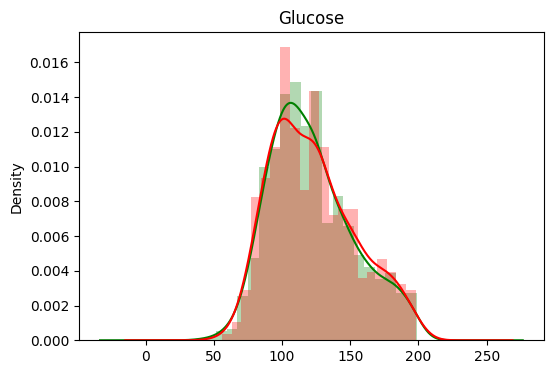

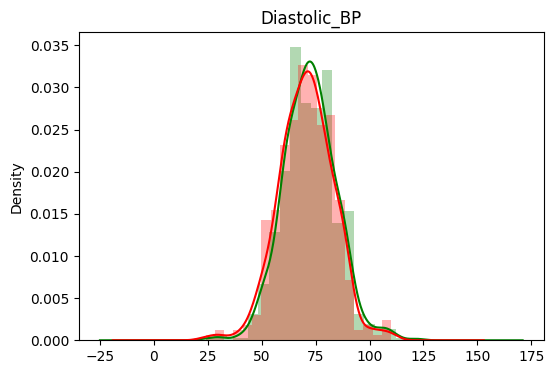

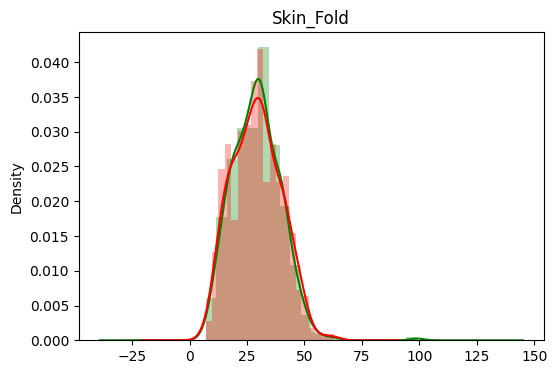

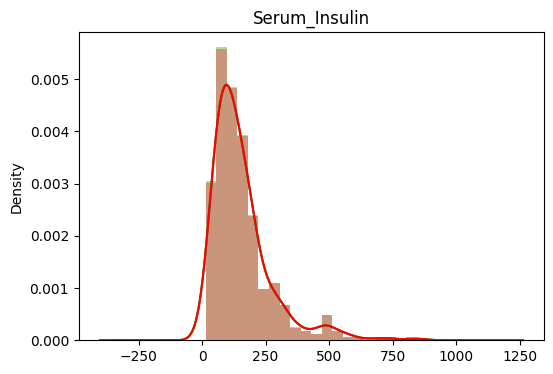

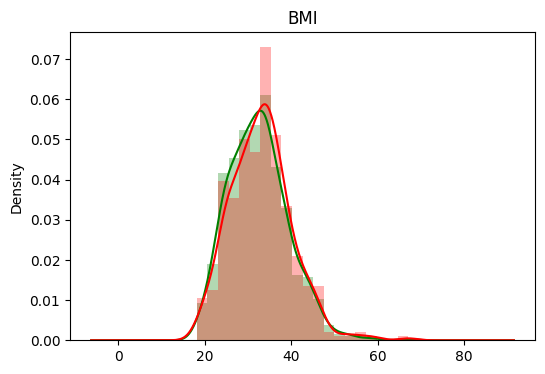

In [17]:
compare_distributions(df[missing_columns], df_dropped_1[missing_columns], bins)

The charts above show changes in the distributions for most features, but these changes are generally not very significant. Let’s see how other changes will affect the distribution of the original data.

## 1.3 Replacing missing values

In [18]:
# Since all the features are numerical, let’s replace them with zeros in the first example
df_filled_0 = df.fillna(0)
df_filled_0.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Pregnant           768 non-null    int64  
 1   Glucose            768 non-null    float64
 2   Diastolic_BP       768 non-null    float64
 3   Skin_Fold          768 non-null    float64
 4   Serum_Insulin      768 non-null    float64
 5   BMI                768 non-null    float64
 6   Diabetes_Pedigree  768 non-null    float64
 7   Age                768 non-null    int64  
 8   Class              768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [19]:
# It is clear that such an operation introduces significant changes to the data distribution, which distorts it considerably
# Furthermore, without domain knowledge, it will likely turn out that inserting a value of 0 for selected
# features is a value that never occurs in real-world measurements! We can certainly confirm this
# for all of the listed features. Of course, this is visible in the histogram, but if we check
# how many 0s appear in the original data in the selected columns, we will see:
display((df == 0).sum())
# or for choden columns only
(df[missing_columns] == 0.0).sum()

Pregnant             111
Glucose                0
Diastolic_BP           0
Skin_Fold              0
Serum_Insulin          0
BMI                    0
Diabetes_Pedigree      0
Age                    0
Class                500
dtype: int64

Glucose          0
Diastolic_BP     0
Skin_Fold        0
Serum_Insulin    0
BMI              0
dtype: int64

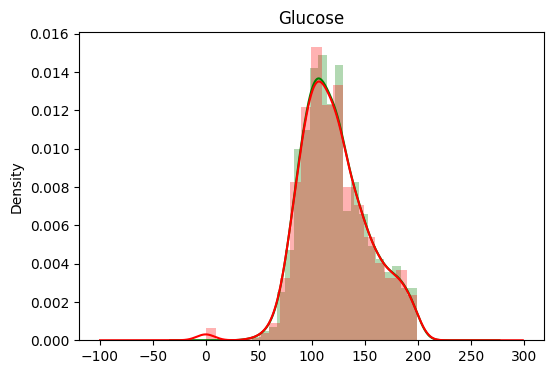

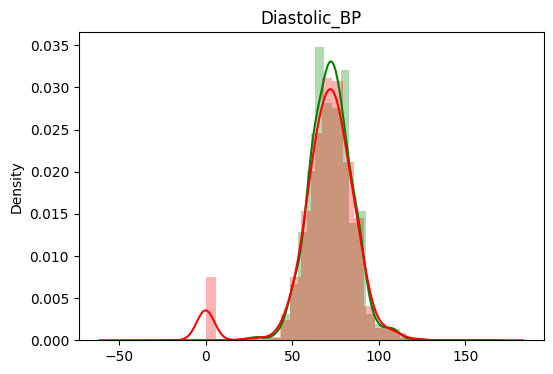

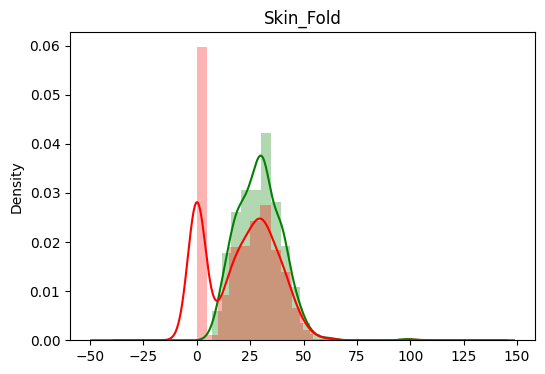

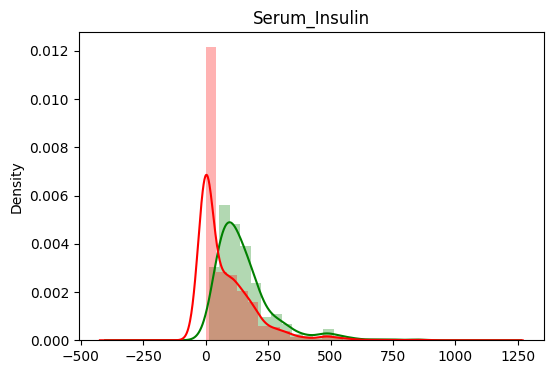

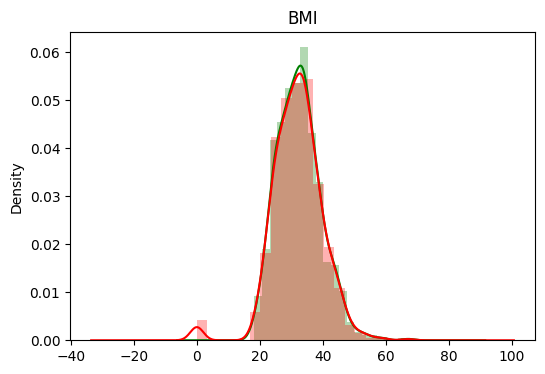

In [20]:
# let's compare the distributions once again
compare_distributions(df[missing_columns], df_filled_0[missing_columns], bins)

Here, we can already see significant data distortion. Let’s look at other possibilities.

In [21]:
# Fill data with the average value (numeric data)
df_filled_mean = df.fillna(df.mean())
df_filled_mean.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Pregnant           768 non-null    int64  
 1   Glucose            768 non-null    float64
 2   Diastolic_BP       768 non-null    float64
 3   Skin_Fold          768 non-null    float64
 4   Serum_Insulin      768 non-null    float64
 5   BMI                768 non-null    float64
 6   Diabetes_Pedigree  768 non-null    float64
 7   Age                768 non-null    int64  
 8   Class              768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


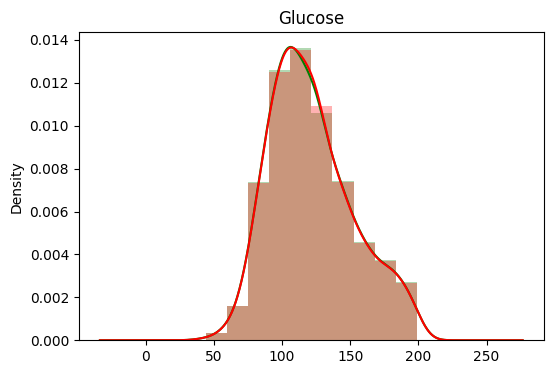

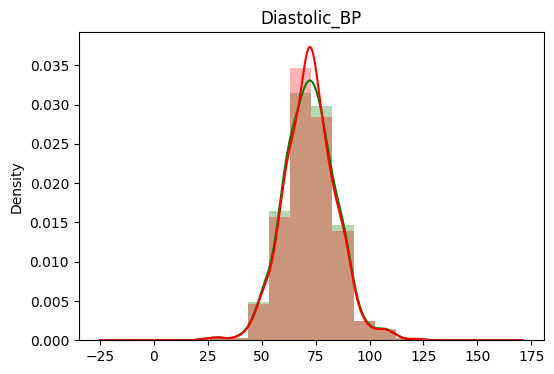

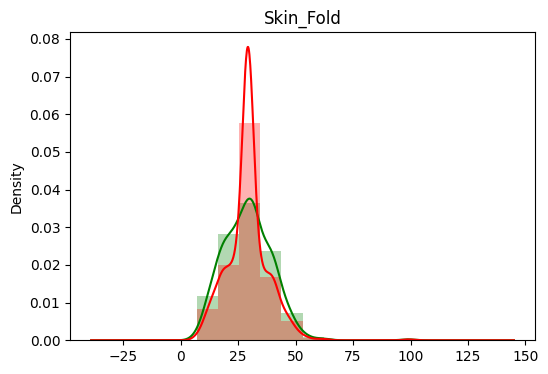

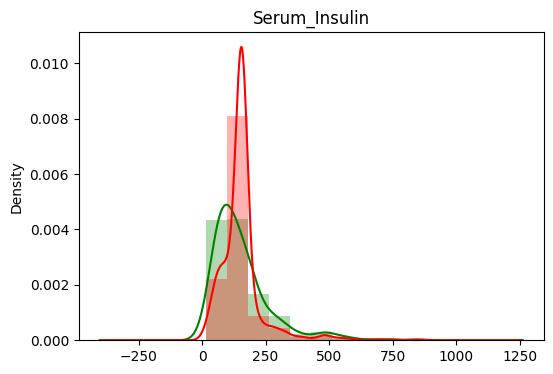

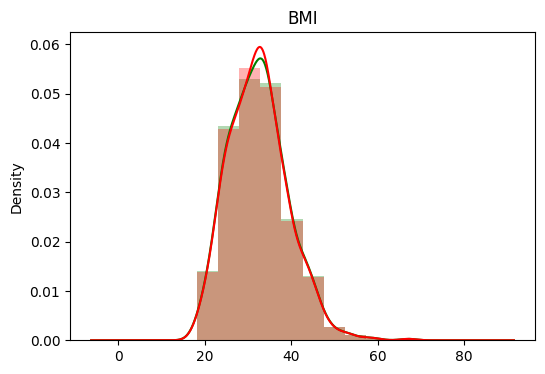

In [22]:
compare_distributions(df[missing_columns], df_filled_mean[missing_columns])

Naturally, with such a change, the distribution will be even more concentrated around the mean of the original distribution.

In [23]:
# Filling with values from the front or back – this means inserting the previous value for an empty value, starting
# from the beginning of the frame/series or from its end
# Let's check this for the attribute that contains the most empty values
df['Serum_Insulin'].head(10), df['Serum_Insulin'].describe()

(0      NaN
 1      NaN
 2      NaN
 3     94.0
 4    168.0
 5      NaN
 6     88.0
 7      NaN
 8    543.0
 9      NaN
 Name: Serum_Insulin, dtype: float64,
 count    394.000000
 mean     155.548223
 std      118.775855
 min       14.000000
 25%       76.250000
 50%      125.000000
 75%      190.000000
 max      846.000000
 Name: Serum_Insulin, dtype: float64)

In [24]:
# forward filling of values
df['Serum_Insulin'].ffill()

0        NaN
1        NaN
2        NaN
3       94.0
4      168.0
       ...  
763    180.0
764    180.0
765    112.0
766    112.0
767    112.0
Name: Serum_Insulin, Length: 768, dtype: float64

In [25]:
# As you can see, this doesn't solve the problem when the first value (depending on the direction) is missing
# So let's add a backfill
df_f_and_b_fill  = df.ffill().bfill()

In [26]:
df_f_and_b_fill.isna().sum()

Pregnant             0
Glucose              0
Diastolic_BP         0
Skin_Fold            0
Serum_Insulin        0
BMI                  0
Diabetes_Pedigree    0
Age                  0
Class                0
dtype: int64

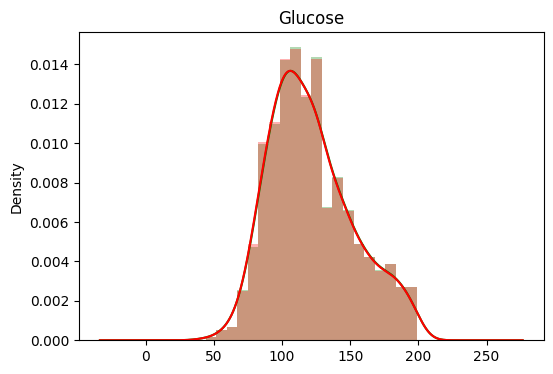

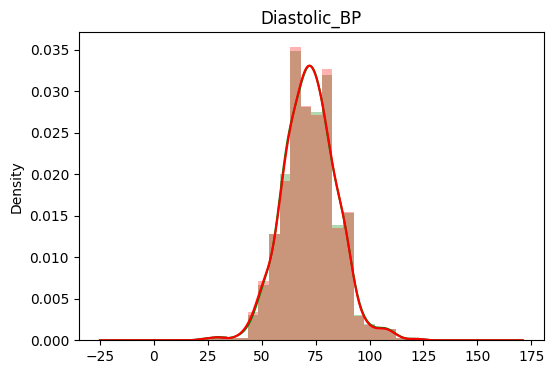

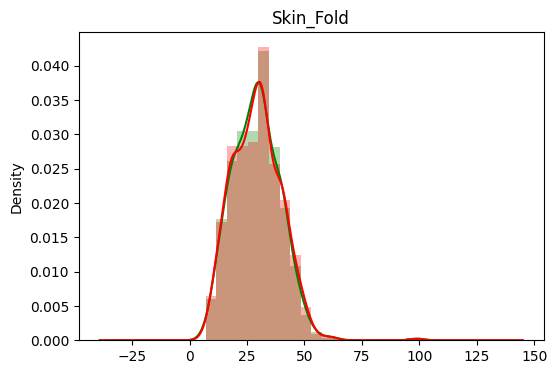

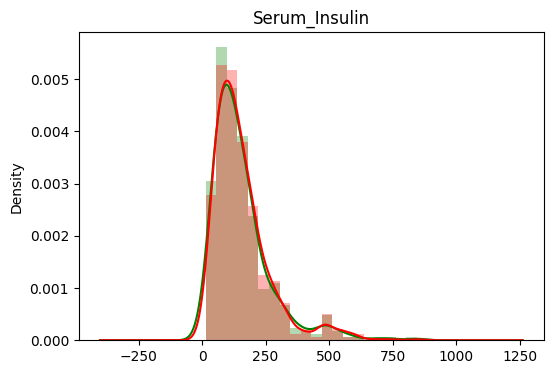

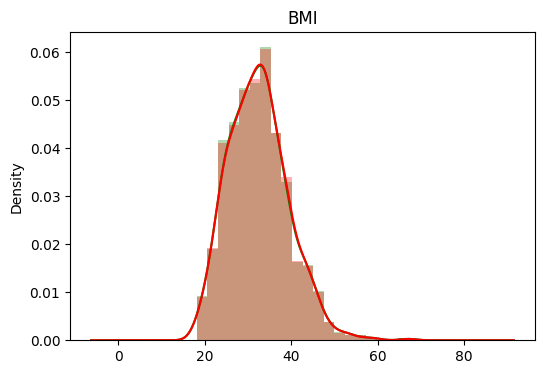

In [27]:
# These operations were successful; let's take a look at the distributions
compare_distributions(df[missing_columns], df_f_and_b_fill[missing_columns], bins)

Changes in the distributions are very small.

**Let's explore possible usage of the `interpolate()` function.**

<Axes: >

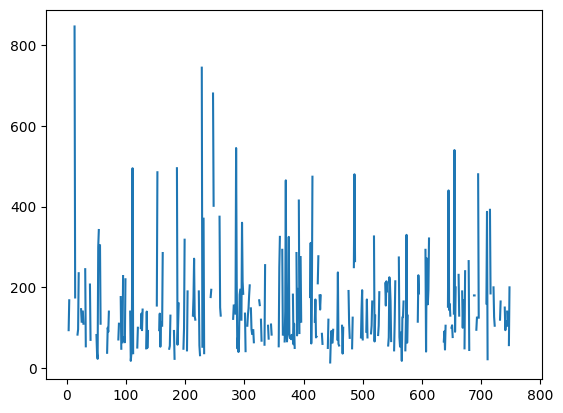

In [28]:
# The chart is quite fragmented due to missing values
df['Serum_Insulin'].plot()

<Axes: >

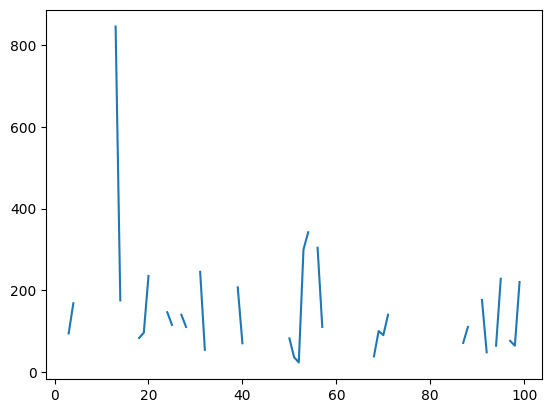

In [29]:
# when we look closer to smaller sample it will be even more visible
df['Serum_Insulin'].iloc[:100].plot()

<Axes: >

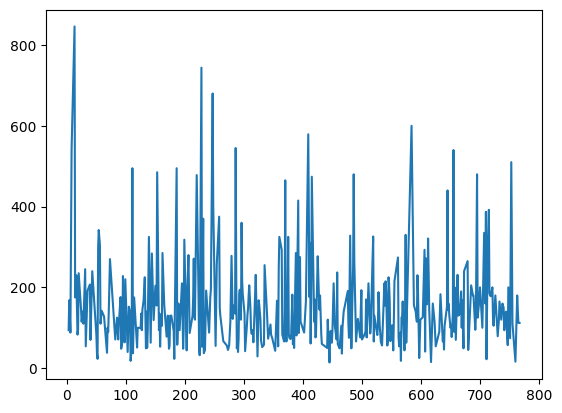

In [30]:
df['Serum_Insulin'].interpolate(method='values').plot()

In [31]:
# If we take a closer look at the data—that is, if we check whether all the missing values have been replaced—we’ll find that they haven’t
df['Serum_Insulin'].interpolate(method='values').isna().sum()

np.int64(3)

In [32]:
# The interpolation function also accepts a `limit_direction` argument, whose default value is `forward`
# You can specify the direction as backward or both (using `backward` and `both`, respectively)
df['Serum_Insulin'].interpolate(method='values', limit_direction='both').isna().sum()

np.int64(0)

In [33]:
# Let's now see the effect for all attributes
df_interpolate = df.interpolate(method='values', limit_direction='both')

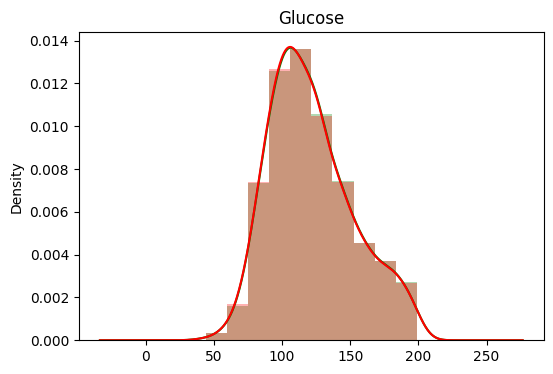

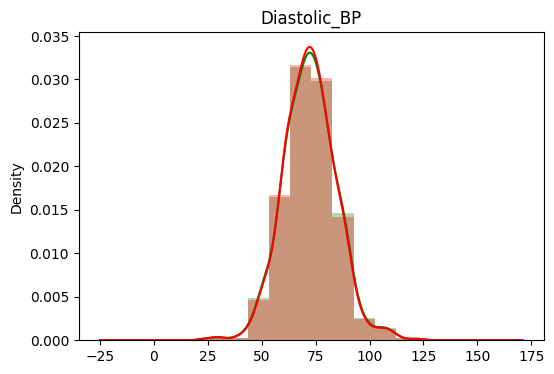

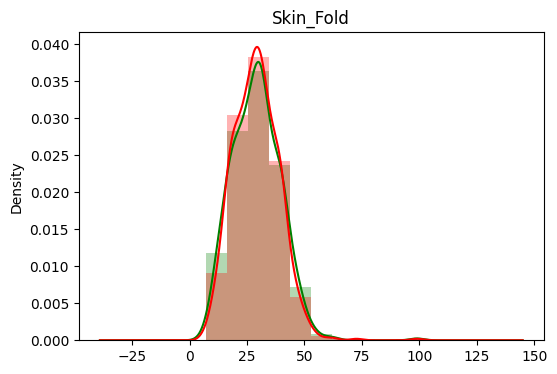

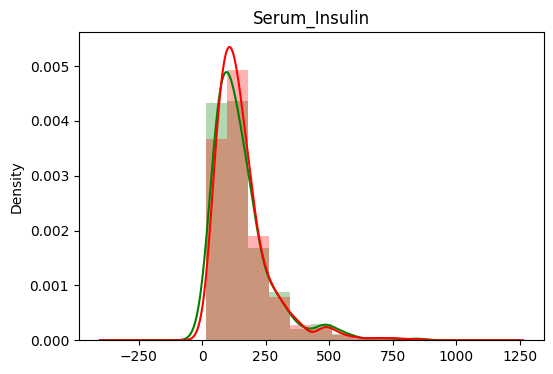

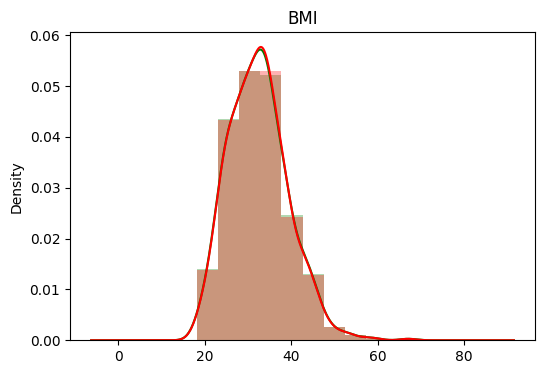

In [34]:
compare_distributions(df[missing_columns], df_interpolate[missing_columns])

As you can see, the result is also good in terms of the degree of distortion in the original data distribution.

## 2. Data aggregation and grouping in pandas

Docs:

* `pandas` group by: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html

In [37]:
df_ord = pd.read_csv(os.path.join(DATAPATH,'orders.csv'), sep=';')

In [38]:
df_ord.head()

,Country,Seller,OrderDate,OrderId,OrderValue
0,Polska,Kowalski,2003-07-16,10248,440.00
1,Polska,Sowiński,2003-07-10,10249,1863.40
2,Niemcy,Peacock,2003-07-12,10250,1552.60
3,Niemcy,Leverling,2003-07-15,10251,654.06
4,Niemcy,Peacock,2003-07-11,10252,3597.90


In [40]:
# Group data by the “Country” column and count the number of occurrences in each group
# Looking at the function signature, the first argument is named `by`
df_ord.groupby('Country').count()

,Seller,OrderDate,OrderId,OrderValue
Country,,,,
Niemcy,584,584,584,584
Polska,215,215,215,215


In [41]:
# The same operation, but written differently, allowing you to specify selected
# columns and aggregations for each one individually
df_ord.groupby(['Country']).agg({'Country':['count']})
# or
df_ord.groupby(by=['Country']).agg({'Country':['count']})

,Country
,count
Country,
Niemcy,584
Polska,215


In [42]:
# Group by country, then by seller, and then count the number of orders and the total for
# each item in the group
df_ord.groupby(['Country', 'Seller']).agg({'OrderId':['count'], 'OrderValue': ['sum', 'mean', 'min']})

OrderId OrderValue                     
                    count        sum         mean     min
Country Seller                                           
Niemcy  Callahan       99  123032.67  1242.754242   36.00
        Davolio       117  182500.09  1559.829829   33.75
        Fuller         92  162503.78  1766.345435   40.00
        Leverling     125  201196.27  1609.570160   45.00
        Peacock       151  225763.68  1495.123709   18.40
Polska  Dudek          41   75048.04  1830.440000   12.50
        King           67  116962.99  1745.716269   60.00
        Kowalski       42   68792.25  1637.910714  103.20
        Sowiński       65   72527.63  1115.809692   48.00

Data grouped using the pandas library is stored in an object of type `pandas.api.typing.DataFrameGroupBy` or `pandas.api.typing.SeriesGroupBy`. We can therefore store the grouped dataframe or series in a separate variable and later calculate various aggregates in separate operations. 

The official documentation lists all operations supported on these data types:

* https://pandas.pydata.org/docs/reference/groupby.html


In [43]:
df_ord_grouped = df_ord.groupby(['Country', 'Seller'])

In [44]:
df_ord_grouped

In [45]:
# data for all groups
df_ord_grouped.groups

{('Niemcy',
  'Callahan'): Index([ 14,  20,  28,  30,  31,  38,  39,  42,  53,  57,  62,  70,  86, 106,
        118, 121, 132, 135, 151, 154, 160, 164, 168, 173, 187, 189, 195, 202,
        204, 207, 208, 212, 219, 224, 228, 233, 240, 243, 250, 273, 285, 286,
        295, 297, 312, 317, 323, 341, 348, 354, 355, 362, 366, 375, 379, 383,
        384, 387, 403, 412, 431, 446, 448, 458, 471, 472, 474, 476, 481, 508,
        522, 538, 547, 563, 576, 596, 597, 604, 609, 614, 635, 639, 684, 692,
        707, 709, 713, 714, 729, 731, 738, 739, 749, 750, 759, 783, 785, 792,
        797],
       dtype='int64'),
 ('Niemcy',
  'Davolio'): Index([ 10,  22,  27,  37,  44,  45,  56,  58,  63,  66,
        ...
        728, 733, 736, 743, 744, 747, 763, 772, 776, 787],
       dtype='int64', length=117),
 ('Niemcy',
  'Fuller'): Index([ 17,  29,  32,  47,  52,  59,  64,  65,  79,  91,  97, 120, 131, 140,
        144, 150, 156, 159, 166, 174, 209, 214, 223, 230, 239, 254, 267, 268,
        293, 304, 305,

In [46]:
df_ord_grouped.groups.keys()

dict_keys([('Niemcy', 'Callahan'), ('Niemcy', 'Davolio'), ('Niemcy', 'Fuller'), ('Niemcy', 'Leverling'), ('Niemcy', 'Peacock'), ('Polska', 'Dudek'), ('Polska', 'King'), ('Polska', 'Kowalski'), ('Polska', 'Sowiński')])

In [47]:
df_ord_grouped.count()

OrderDate  OrderId  OrderValue
Country Seller                                   
Niemcy  Callahan          99       99          99
        Davolio          117      117         117
        Fuller            92       92          92
        Leverling        125      125         125
        Peacock          151      151         151
Polska  Dudek             41       41          41
        King              67       67          67
        Kowalski          42       42          42
        Sowiński          65       65          65

In [48]:
# Data aggregation, as in the previous examples; here, data sorting has also been added
# by the aggregated column, using a multi-index (in the form of a tuple), in ascending order by default
df_ord_grouped.agg({'OrderValue': ['sum', 'mean']}).sort_values([('OrderValue','sum')])

OrderValue             
                         sum         mean
Country Seller                           
Polska  Kowalski    68792.25  1637.910714
        Sowiński    72527.63  1115.809692
        Dudek       75048.04  1830.440000
        King       116962.99  1745.716269
Niemcy  Callahan   123032.67  1242.754242
        Fuller     162503.78  1766.345435
        Davolio    182500.09  1559.829829
        Leverling  201196.27  1609.570160
        Peacock    225763.68  1495.123709

In [49]:
# and sorting in descending order
df_ord_grouped.agg({'OrderValue': ['sum', 'mean']}).sort_values([('OrderValue','sum')], ascending=False)

OrderValue             
                         sum         mean
Country Seller                           
Niemcy  Peacock    225763.68  1495.123709
        Leverling  201196.27  1609.570160
        Davolio    182500.09  1559.829829
        Fuller     162503.78  1766.345435
        Callahan   123032.67  1242.754242
Polska  King       116962.99  1745.716269
        Dudek       75048.04  1830.440000
        Sowiński    72527.63  1115.809692
        Kowalski    68792.25  1637.910714

In [50]:
# Returns the nth smallest or largest value—these functions are only available for the SeriesGroupBy type
df_ord_grouped.agg({'OrderValue': ['sum', 'mean']})[('OrderValue','sum')].nlargest(3)

Country  Seller   
Niemcy   Peacock      225763.68
         Leverling    201196.27
         Davolio      182500.09
Name: (OrderValue, sum), dtype: float64

In [51]:
df_ord_grouped['OrderId'].count().nsmallest(3)

Country  Seller  
Polska   Dudek       41
         Kowalski    42
         Sowiński    65
Name: OrderId, dtype: int64

In [52]:
df_ord.head()

,Country,Seller,OrderDate,OrderId,OrderValue
0,Polska,Kowalski,2003-07-16,10248,440.00
1,Polska,Sowiński,2003-07-10,10249,1863.40
2,Niemcy,Peacock,2003-07-12,10250,1552.60
3,Niemcy,Leverling,2003-07-15,10251,654.06
4,Niemcy,Peacock,2003-07-11,10252,3597.90


In [53]:
# sample of 1% values from OrderId column
df_ord['OrderId'].sample(frac=0.01)

44     10292
572    10820
472    10720
350    10598
783    11034
293    10541
701    10949
480    10728
Name: OrderId, dtype: int64

**Below example could be used to randomly put a given percentage of missing values within the single column of pandas DataFrame.**

In [55]:
# We substitute 85% of the values randomly selected from the original dataset (the indices are randomly selected),
# assigning them to the same column, which means that approximately 15% of the values
# that were not randomly selected will take on the value “nan”
df_ord['OrderId'] = df_ord['OrderId'].sample(frac=0.85)

In [56]:
df_ord['OrderId'].isna().sum() / df.shape[0]

np.float64(0.15625)

## 4. Tasks

**Task 1**

For the dataset `orders.csv`, do the following:
* 1.1 Load the data and check for any missing values.
* 1.2 In the `Seller` column, randomly replace 10% of the values with the word ‘MISSING’. (see the pseudo-random functions in the pandas or numpy libraries and use the exercises from previous classes on indexing data in frames/series)
* 1.3 In the `OrderID` column, replace 5% of the values with `np.nan`.
* 1.4 In the `OrderDate` column, replace 20% of the values with `e.g., nan`.
* 1.5 In the `OrderValue` column, replace 15% of the values with `e.g., nan`.
* 1.6 Save the dataset with missing values in a separate variable.

**Task 2**

For the new dataset (with missing values) from Task 1, do the following:
* 2.1 Replace missing values in the `OrderId` column with 0.
* 2.2 Replace missing values in the `OrderDate` column with forward-fill values (`ffill()`).
* 2.3 Replace missing values in the `OrderValue` column with the average value for the given country.

**Task 3**

Display the distributions of the `OrderValue` feature for the original dataset and the dataset after executing the commands from Task 2 in histogram charts with a distribution function (exactly as in the examples above).

**Task 4**  

Based on the examples from Section 2 and the `orders.csv` dataset, calculate:

* 4.1 The average order value for each country.
* 4.2 The average order value for each year, and then for each month (two-level grouping).
* 4.3 The number of orders placed by each seller in a given year.
* 4.4 The name of the seller from each country with the highest total revenue.
* 4.5 The total revenue for each quarter (including the year), and sort by descending order.